In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

economic = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "economic_master.csv"
)

economic["date"] = pd.to_datetime(economic["date"])

economic = (
    economic
    .sort_values("date")
    .reset_index(drop=True)
)

economic.head()

,date,year,month,cpi_index,inflation,wpi_inflation,repo_rate
0,2013-01-01,2013,January,55.1,NaN,NaN,7.75
1,2013-02-01,2013,February,55.5,NaN,NaN,7.75
2,2013-03-01,2013,March,55.6,NaN,NaN,7.50
3,2013-04-01,2013,April,55.9,NaN,3.724928,7.50
4,2013-05-01,2013,May,56.3,NaN,3.133903,7.25


In [3]:
# Create next-month inflation target

economic["target_inflation_next_month"] = (
    economic["inflation"].shift(-1)
)

economic[
    [
        "date",
        "inflation",
        "target_inflation_next_month"
    ]
].tail(10)

,date,inflation,target_inflation_next_month
153,2025-10-01,0.038573,0.492754
154,2025-11-01,0.492754,1.166181
155,2025-12-01,1.166181,2.734337
156,2026-01-01,2.734337,3.207659
157,2026-02-01,3.207659,3.402702
158,2026-03-01,3.402702,3.484938
159,2026-04-01,3.484938,3.935231
160,2026-05-01,3.935231,4.380060
161,2026-06-01,4.380060,4.441219
162,2026-07-01,4.441219,NaN


In [4]:
# Create CPI lag features

lag_periods = [1, 2, 3, 6, 12]

for lag in lag_periods:
    economic[f"inflation_lag_{lag}"] = (
        economic["inflation"].shift(lag)
    )

economic[
    [
        "date",
        "inflation",
        "inflation_lag_1",
        "inflation_lag_2",
        "inflation_lag_3",
        "inflation_lag_6",
        "inflation_lag_12"
    ]
].tail(15)

,date,inflation,inflation_lag_1,inflation_lag_2,inflation_lag_3,inflation_lag_6,inflation_lag_12
148,2025-05-01,3.033367,3.336724,3.564862,3.493361,5.480000,4.800000
149,2025-06-01,2.305389,3.033367,3.336724,3.564862,5.220000,5.080000
150,2025-07-01,1.622419,2.305389,3.033367,3.336724,4.063460,3.600000
151,2025-08-01,2.005900,1.622419,2.305389,3.033367,3.493361,3.650000
152,2025-09-01,1.407625,2.005900,1.622419,2.305389,3.564862,5.490000
153,2025-10-01,0.038573,1.407625,2.005900,1.622419,3.336724,6.210000
154,2025-11-01,0.492754,0.038573,1.407625,2.005900,3.033367,5.480000
155,2025-12-01,1.166181,0.492754,0.038573,1.407625,2.305389,5.220000
156,2026-01-01,2.734337,1.166181,0.492754,0.038573,1.622419,4.063460
157,2026-02-01,3.207659,2.734337,1.166181,0.492754,2.005900,3.493361


In [5]:
# Create WPI lag features

wpi_lag_periods = [1, 2, 3, 6]

economic["wpi_inflation_current"] = economic["wpi_inflation"]

for lag in wpi_lag_periods:
    economic[f"wpi_inflation_lag_{lag}"] = (
        economic["wpi_inflation"].shift(lag)
    )

economic[
    [
        "date",
        "inflation",
        "wpi_inflation_current",
        "wpi_inflation_lag_1",
        "wpi_inflation_lag_2",
        "wpi_inflation_lag_3",
        "wpi_inflation_lag_6"
    ]
].tail(15)

,date,inflation,wpi_inflation_current,wpi_inflation_lag_1,wpi_inflation_lag_2,wpi_inflation_lag_3,wpi_inflation_lag_6
148,2025-05-01,3.033367,-0.199203,0.600601,1.207243,1.611279,1.998002
149,2025-06-01,2.305389,-0.397219,-0.199203,0.600601,1.207243,2.213280
150,2025-07-01,1.622419,-0.792079,-0.397219,-0.199203,0.600601,1.812689
151,2025-08-01,2.005900,0.000000,-0.792079,-0.397219,-0.199203,1.611279
152,2025-09-01,1.407625,-0.197628,0.000000,-0.792079,-0.397219,1.207243
153,2025-10-01,0.038573,-1.175318,-0.197628,0.000000,-0.792079,0.600601
154,2025-11-01,0.492754,-0.587659,-1.175318,-0.197628,0.000000,-0.199203
155,2025-12-01,1.166181,0.295276,-0.587659,-1.175318,-0.197628,-0.397219
156,2026-01-01,2.734337,1.186944,0.295276,-0.587659,-1.175318,-0.792079
157,2026-02-01,3.207659,2.180377,1.186944,0.295276,-0.587659,0.000000


In [6]:
# Create RBI repo rate features

repo_lag_periods = [1, 3, 6]

economic["repo_rate_current"] = economic["repo_rate"]

for lag in repo_lag_periods:
    economic[f"repo_rate_lag_{lag}"] = (
        economic["repo_rate"].shift(lag)
    )

economic[
    [
        "date",
        "inflation",
        "repo_rate_current",
        "repo_rate_lag_1",
        "repo_rate_lag_3",
        "repo_rate_lag_6"
    ]
].tail(15)

,date,inflation,repo_rate_current,repo_rate_lag_1,repo_rate_lag_3,repo_rate_lag_6
148,2025-05-01,3.033367,6.00,6.00,6.25,6.50
149,2025-06-01,2.305389,5.50,6.00,6.25,6.50
150,2025-07-01,1.622419,5.50,5.50,6.00,6.50
151,2025-08-01,2.005900,5.50,5.50,6.00,6.25
152,2025-09-01,1.407625,5.50,5.50,5.50,6.25
153,2025-10-01,0.038573,5.50,5.50,5.50,6.00
154,2025-11-01,0.492754,5.50,5.50,5.50,6.00
155,2025-12-01,1.166181,5.25,5.50,5.50,5.50
156,2026-01-01,2.734337,5.25,5.25,5.50,5.50
157,2026-02-01,3.207659,5.25,5.25,5.50,5.50


In [7]:
# Create repo rate change features

economic["repo_rate_change"] = (
    economic["repo_rate"].diff()
)

economic["repo_rate_change_lag_1"] = (
    economic["repo_rate_change"].shift(1)
)

economic["repo_rate_change_lag_3"] = (
    economic["repo_rate_change"].shift(3)
)

economic[
    [
        "date",
        "repo_rate",
        "repo_rate_change",
        "repo_rate_change_lag_1",
        "repo_rate_change_lag_3"
    ]
].tail(20)

,date,repo_rate,repo_rate_change,repo_rate_change_lag_1,repo_rate_change_lag_3
143,2024-12-01,6.50,0.00,0.00,0.00
144,2025-01-01,6.50,0.00,0.00,0.00
145,2025-02-01,6.25,-0.25,0.00,0.00
146,2025-03-01,6.25,0.00,-0.25,0.00
147,2025-04-01,6.00,-0.25,0.00,0.00
148,2025-05-01,6.00,0.00,-0.25,-0.25
149,2025-06-01,5.50,-0.50,0.00,0.00
150,2025-07-01,5.50,0.00,-0.50,-0.25
151,2025-08-01,5.50,0.00,0.00,0.00
152,2025-09-01,5.50,0.00,0.00,-0.50


In [8]:
# Create rolling inflation features

economic["inflation_rolling_mean_3"] = (
    economic["inflation"]
    .rolling(window=3)
    .mean()
)

economic["inflation_rolling_mean_6"] = (
    economic["inflation"]
    .rolling(window=6)
    .mean()
)

economic["inflation_rolling_std_3"] = (
    economic["inflation"]
    .rolling(window=3)
    .std()
)

economic[
    [
        "date",
        "inflation",
        "inflation_rolling_mean_3",
        "inflation_rolling_mean_6",
        "inflation_rolling_std_3"
    ]
].tail(15)

,date,inflation,inflation_rolling_mean_3,inflation_rolling_mean_6,inflation_rolling_std_3
148,2025-05-01,3.033367,3.311651,3.785296,0.266633
149,2025-06-01,2.305389,2.891827,3.299527,0.530036
150,2025-07-01,1.622419,2.320392,2.892687,0.705594
151,2025-08-01,2.005900,1.977903,2.644777,0.342345
152,2025-09-01,1.407625,1.678648,2.285237,0.303075
153,2025-10-01,0.038573,1.150699,1.735545,1.008515
154,2025-11-01,0.492754,0.646317,1.312110,0.697325
155,2025-12-01,1.166181,0.565836,1.122242,0.567345
156,2026-01-01,2.734337,1.464424,1.307561,1.150167
157,2026-02-01,3.207659,2.369392,1.507855,1.068549


In [9]:
# Create seasonal month features

economic["month_num"] = economic["date"].dt.month

economic["month_sin"] = (
    __import__("numpy").sin(
        2 * __import__("numpy").pi
        * economic["month_num"] / 12
    )
)

economic["month_cos"] = (
    __import__("numpy").cos(
        2 * __import__("numpy").pi
        * economic["month_num"] / 12
    )
)

economic[
    [
        "date",
        "month",
        "month_num",
        "month_sin",
        "month_cos"
    ]
].tail(15)

,date,month,month_num,month_sin,month_cos
148,2025-05-01,May,5,5.000000e-01,-8.660254e-01
149,2025-06-01,June,6,1.224647e-16,-1.000000e+00
150,2025-07-01,July,7,-5.000000e-01,-8.660254e-01
151,2025-08-01,August,8,-8.660254e-01,-5.000000e-01
152,2025-09-01,September,9,-1.000000e+00,-1.836970e-16
153,2025-10-01,October,10,-8.660254e-01,5.000000e-01
154,2025-11-01,November,11,-5.000000e-01,8.660254e-01
155,2025-12-01,December,12,-2.449294e-16,1.000000e+00
156,2026-01-01,January,1,5.000000e-01,8.660254e-01
157,2026-02-01,February,2,8.660254e-01,5.000000e-01


In [10]:
# Inspect the complete feature dataset

print("Shape:", economic.shape)

print("\nColumns:")
print(economic.columns.tolist())

print("\nMissing values:")
print(economic.isna().sum())

Shape: (163, 31)

Columns:
['date', 'year', 'month', 'cpi_index', 'inflation', 'wpi_inflation', 'repo_rate', 'target_inflation_next_month', 'inflation_lag_1', 'inflation_lag_2', 'inflation_lag_3', 'inflation_lag_6', 'inflation_lag_12', 'wpi_inflation_current', 'wpi_inflation_lag_1', 'wpi_inflation_lag_2', 'wpi_inflation_lag_3', 'wpi_inflation_lag_6', 'repo_rate_current', 'repo_rate_lag_1', 'repo_rate_lag_3', 'repo_rate_lag_6', 'repo_rate_change', 'repo_rate_change_lag_1', 'repo_rate_change_lag_3', 'inflation_rolling_mean_3', 'inflation_rolling_mean_6', 'inflation_rolling_std_3', 'month_num', 'month_sin', 'month_cos']

Missing values:
date                            0
year                            0
month                           0
cpi_index                       0
inflation                      12
wpi_inflation                   3
repo_rate                       0
target_inflation_next_month    12
inflation_lag_1                13
inflation_lag_2                14
inflation_lag_3   

<h3> Define modelling features

In [11]:
# Define features for the forecasting model

feature_columns = [
    # Current inflation
    "inflation",

    # CPI history
    "inflation_lag_2",
    "inflation_lag_3",
    "inflation_lag_6",
    "inflation_lag_12",

    # WPI
    "wpi_inflation_current",
    "wpi_inflation_lag_1",
    "wpi_inflation_lag_2",
    "wpi_inflation_lag_3",
    "wpi_inflation_lag_6",

    # RBI repo rate
    "repo_rate_current",
    "repo_rate_lag_1",
    "repo_rate_lag_3",
    "repo_rate_lag_6",

    # RBI policy changes
    "repo_rate_change",
    "repo_rate_change_lag_1",
    "repo_rate_change_lag_3",

    # Inflation trend
    "inflation_rolling_mean_3",
    "inflation_rolling_mean_6",
    "inflation_rolling_std_3",

    # Seasonality
    "month_num",
    "month_sin",
    "month_cos"
]

target_column = "target_inflation_next_month"

print("Number of features:", len(feature_columns))

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget:")
print("-", target_column)

Number of features: 23

Features:
- inflation
- inflation_lag_2
- inflation_lag_3
- inflation_lag_6
- inflation_lag_12
- wpi_inflation_current
- wpi_inflation_lag_1
- wpi_inflation_lag_2
- wpi_inflation_lag_3
- wpi_inflation_lag_6
- repo_rate_current
- repo_rate_lag_1
- repo_rate_lag_3
- repo_rate_lag_6
- repo_rate_change
- repo_rate_change_lag_1
- repo_rate_change_lag_3
- inflation_rolling_mean_3
- inflation_rolling_mean_6
- inflation_rolling_std_3
- month_num
- month_sin
- month_cos

Target:
- target_inflation_next_month


In [12]:
# Create modeling dataset

model_df = economic[
    feature_columns + [target_column]
].copy()

print("Before removing missing values:")
print("Rows:", len(model_df))

print("\nMissing values:")
print(model_df.isna().sum())

# Keep only observations where every required
# feature and the target are available
model_df = model_df.dropna().copy()

print("\nAfter removing missing values:")
print("Rows:", len(model_df))

Before removing missing values:
Rows: 163

Missing values:
inflation                      12
inflation_lag_2                14
inflation_lag_3                15
inflation_lag_6                18
inflation_lag_12               24
wpi_inflation_current           3
wpi_inflation_lag_1             4
wpi_inflation_lag_2             5
wpi_inflation_lag_3             6
wpi_inflation_lag_6             9
repo_rate_current               0
repo_rate_lag_1                 1
repo_rate_lag_3                 3
repo_rate_lag_6                 6
repo_rate_change                1
repo_rate_change_lag_1          2
repo_rate_change_lag_3          4
inflation_rolling_mean_3       14
inflation_rolling_mean_6       17
inflation_rolling_std_3        14
month_num                       0
month_sin                       0
month_cos                       0
target_inflation_next_month    12
dtype: int64

After removing missing values:
Rows: 138


In [13]:
# Check the final modeling dataset

print("=" * 60)
print("FINAL MODELING DATASET CHECK")
print("=" * 60)

print("\nShape:")
print(model_df.shape)

print("\nFirst 5 rows:")
print(model_df.head().to_string(index=False))

print("\nLast 5 rows:")
print(model_df.tail().to_string(index=False))

FINAL MODELING DATASET CHECK

Shape:
(138, 24)

First 5 rows:
 inflation  inflation_lag_2  inflation_lag_3  inflation_lag_6  inflation_lag_12  wpi_inflation_current  wpi_inflation_lag_1  wpi_inflation_lag_2  wpi_inflation_lag_3  wpi_inflation_lag_6  repo_rate_current  repo_rate_lag_1  repo_rate_lag_3  repo_rate_lag_6  repo_rate_change  repo_rate_change_lag_1  repo_rate_change_lag_3  inflation_rolling_mean_3  inflation_rolling_mean_6  inflation_rolling_std_3  month_num  month_sin     month_cos  target_inflation_next_month
      5.19             3.27             4.62             7.39              8.60              -2.464789            -1.146384            -0.174978             0.872600             4.946043               7.75             8.00             8.00              8.0             -0.25                    0.00                    0.00                  4.246667                  5.003333                 0.960434          1   0.500000  8.660254e-01                         5.37
      5.

In [19]:
# Verify the actual dates represented by the modeling rows

training_dates = economic.loc[
    model_df.index,
    "date"
]

print("\nTraining date range:")
print(
    training_dates.min().date(),
    "→",
    training_dates.max().date()
)


Training date range:
2015-01-01 → 2026-06-01


<h3>Train Test & Validation

In [15]:
# Create chronological train / validation / test split

n = len(model_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
validation_df = model_df.iloc[train_end:validation_end].copy()
test_df = model_df.iloc[validation_end:].copy()

print("=" * 60)
print("TIME-BASED DATA SPLIT")
print("=" * 60)

print("\nTotal observations:", n)

print("\nTraining set:")
print("Rows:", len(train_df))

print("\nValidation set:")
print("Rows:", len(validation_df))

print("\nTest set:")
print("Rows:", len(test_df))

TIME-BASED DATA SPLIT

Total observations: 138

Training set:
Rows: 96

Validation set:
Rows: 21

Test set:
Rows: 21


In [21]:
# Separate features and target

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_val = validation_df[feature_columns]
y_val = validation_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (96, 23)
y_train: (96,)
X_val: (21, 23)
y_val: (21,)
X_test: (21, 23)
y_test: (21,)


<h3> Creating a Naive Baseline model

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive prediction:
# Predict next month's inflation using current month's inflation

val_predictions_naive = X_val["inflation"]
test_predictions_naive = X_test["inflation"]

# Validation metrics
val_mae_naive = mean_absolute_error(y_val, val_predictions_naive)
val_rmse_naive = np.sqrt(
    mean_squared_error(y_val, val_predictions_naive)
)

# Test metrics
test_mae_naive = mean_absolute_error(y_test, test_predictions_naive)
test_rmse_naive = np.sqrt(
    mean_squared_error(y_test, test_predictions_naive)
)

print("=" * 60)
print("NAIVE BASELINE MODEL")
print("=" * 60)

print("\nVALIDATION SET")
print(f"MAE:  {val_mae_naive:.4f}")
print(f"RMSE: {val_rmse_naive:.4f}")

print("\nTEST SET")
print(f"MAE:  {test_mae_naive:.4f}")
print(f"RMSE: {test_rmse_naive:.4f}")

NAIVE BASELINE MODEL

VALIDATION SET
MAE:  0.6662
RMSE: 0.9597

TEST SET
MAE:  0.5469
RMSE: 0.6754


<h3>Ridge Regression model

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create Ridge Regression pipeline
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

# Train model
ridge_model.fit(X_train, y_train)

# Predictions
val_predictions_ridge = ridge_model.predict(X_val)

# Validation metrics
val_mae_ridge = mean_absolute_error(y_val, val_predictions_ridge)

val_rmse_ridge = np.sqrt(
    mean_squared_error(y_val, val_predictions_ridge)
)

print("=" * 60)
print("RIDGE REGRESSION MODEL")
print("=" * 60)

print(f"\nValidation MAE:  {val_mae_ridge:.4f}")
print(f"Validation RMSE: {val_rmse_ridge:.4f}")

print("\nNaive Baseline Comparison:")
print(f"Naive MAE:       {val_mae_naive:.4f}")
print(f"Naive RMSE:      {val_rmse_naive:.4f}")

RIDGE REGRESSION MODEL

Validation MAE:  0.7318
Validation RMSE: 0.9383

Naive Baseline Comparison:
Naive MAE:       0.6662
Naive RMSE:      0.9597


<h3>Random Forest model

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict validation data
val_predictions_rf = rf_model.predict(X_val)

# Calculate metrics
val_mae_rf = mean_absolute_error(y_val, val_predictions_rf)

val_rmse_rf = np.sqrt(
    mean_squared_error(y_val, val_predictions_rf)
)

print("=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)

print(f"\nValidation MAE:  {val_mae_rf:.4f}")
print(f"Validation RMSE: {val_rmse_rf:.4f}")

print("\nComparison:")
print(f"Naive MAE:       {val_mae_naive:.4f}")
print(f"Ridge MAE:       {val_mae_ridge:.4f}")
print(f"Random Forest MAE: {val_mae_rf:.4f}")

print("\nRMSE Comparison:")
print(f"Naive RMSE:        {val_rmse_naive:.4f}")
print(f"Ridge RMSE:        {val_rmse_ridge:.4f}")
print(f"Random Forest RMSE: {val_rmse_rf:.4f}")

RANDOM FOREST MODEL

Validation MAE:  0.6372
Validation RMSE: 0.9052

Comparison:
Naive MAE:       0.6662
Ridge MAE:       0.7318
Random Forest MAE: 0.6372

RMSE Comparison:
Naive RMSE:        0.9597
Ridge RMSE:        0.9383
Random Forest RMSE: 0.9052


<h3>XGBoost Model

In [25]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [26]:
from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict validation data
val_predictions_xgb = xgb_model.predict(X_val)

# Calculate metrics
val_mae_xgb = mean_absolute_error(
    y_val,
    val_predictions_xgb
)

val_rmse_xgb = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions_xgb
    )
)

print("=" * 60)
print("XGBOOST MODEL")
print("=" * 60)

print(f"\nValidation MAE:  {val_mae_xgb:.4f}")
print(f"Validation RMSE: {val_rmse_xgb:.4f}")

print("\nMODEL COMPARISON")

print(f"Naive MAE:         {val_mae_naive:.4f}")
print(f"Ridge MAE:         {val_mae_ridge:.4f}")
print(f"Random Forest MAE: {val_mae_rf:.4f}")
print(f"XGBoost MAE:       {val_mae_xgb:.4f}")

print("\nRMSE COMPARISON")

print(f"Naive RMSE:         {val_rmse_naive:.4f}")
print(f"Ridge RMSE:         {val_rmse_ridge:.4f}")
print(f"Random Forest RMSE: {val_rmse_rf:.4f}")
print(f"XGBoost RMSE:       {val_rmse_xgb:.4f}")

XGBOOST MODEL

Validation MAE:  0.6397
Validation RMSE: 0.9098

MODEL COMPARISON
Naive MAE:         0.6662
Ridge MAE:         0.7318
Random Forest MAE: 0.6372
XGBoost MAE:       0.6397

RMSE COMPARISON
Naive RMSE:         0.9597
Ridge RMSE:         0.9383
Random Forest RMSE: 0.9052
XGBoost RMSE:       0.9098


<h3>Tune Random Forest

In [27]:
from sklearn.model_selection import ParameterGrid

# Small parameter grid
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 3, 5]
}

results = []

for params in ParameterGrid(param_grid):

    model = RandomForestRegressor(
        random_state=42,
        **params
    )

    # Train
    model.fit(X_train, y_train)

    # Predict validation data
    predictions = model.predict(X_val)

    # Metrics
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    results.append({
        **params,
        "validation_mae": mae,
        "validation_rmse": rmse
    })

results_df = pd.DataFrame(results)

# Sort by MAE
results_df = results_df.sort_values(
    "validation_mae"
)

print("TOP 10 RANDOM FOREST CONFIGURATIONS")
print(results_df.head(10).to_string(index=False))

TOP 10 RANDOM FOREST CONFIGURATIONS
 max_depth  min_samples_leaf  n_estimators  validation_mae  validation_rmse
         3                 5           200        0.621187         0.901368
         3                 3           200        0.624367         0.906350
         3                 5           300        0.624806         0.902963
         3                 2           200        0.624906         0.915321
         3                 5           500        0.625061         0.906576
         3                 2           300        0.625533         0.916017
         3                 3           300        0.626199         0.906225
         3                 2           500        0.627381         0.919642
         3                 3           500        0.627782         0.912593
         5                 5           300        0.630542         0.905421


In [28]:
# Final tuned Random Forest model

best_rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

# Train on training data
best_rf_model.fit(X_train, y_train)

# Validation predictions
val_predictions_best_rf = best_rf_model.predict(X_val)

# Validation metrics
best_rf_val_mae = mean_absolute_error(
    y_val,
    val_predictions_best_rf
)

best_rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions_best_rf
    )
)

print("=" * 60)
print("FINAL TUNED RANDOM FOREST")
print("=" * 60)

print(f"\nValidation MAE:  {best_rf_val_mae:.4f}")
print(f"Validation RMSE: {best_rf_val_rmse:.4f}")

FINAL TUNED RANDOM FOREST

Validation MAE:  0.6212
Validation RMSE: 0.9014


VALIDATION PREDICTIONS
 Actual Inflation  Predicted Inflation  Absolute Error
             6.44                6.246           0.194
             5.66                6.251           0.591
             4.70                6.047           1.347
             4.31                4.834           0.524
             4.87                4.626           0.244
             7.44                4.869           2.571
             6.83                6.576           0.254
             5.02                6.352           1.332
             4.87                4.873           0.003
             5.55                4.837           0.713
             5.69                5.525           0.165
             5.10                5.685           0.585
             5.09                4.894           0.196
             4.85                4.954           0.104
             4.83                4.847           0.017
             4.80                4.831           0.031
             5.08                4.853    

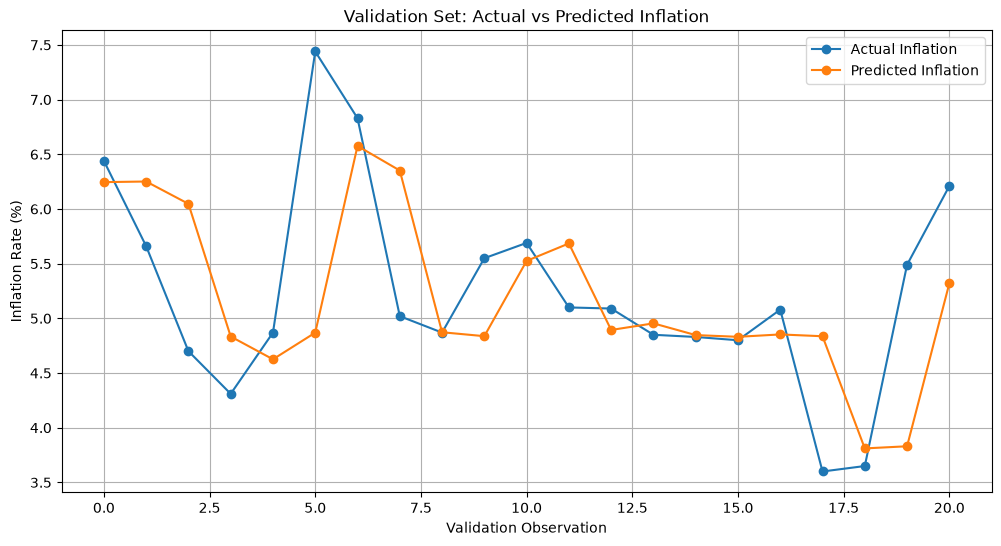

In [29]:
import matplotlib.pyplot as plt

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual Inflation": y_val.values,
    "Predicted Inflation": val_predictions_best_rf
})

comparison_df["Absolute Error"] = (
    comparison_df["Actual Inflation"]
    - comparison_df["Predicted Inflation"]
).abs()

print("VALIDATION PREDICTIONS")
print(comparison_df.round(3).to_string(index=False))


# Plot actual vs predicted inflation
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_df["Actual Inflation"].values,
    marker="o",
    label="Actual Inflation"
)

plt.plot(
    comparison_df["Predicted Inflation"].values,
    marker="o",
    label="Predicted Inflation"
)

plt.title("Validation Set: Actual vs Predicted Inflation")
plt.xlabel("Validation Observation")
plt.ylabel("Inflation Rate (%)")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
# Random Forest Feature Importance

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance_df
    .head(15)
    .to_string(index=False)
)

RANDOM FOREST FEATURE IMPORTANCE
                 Feature  Importance
               inflation    0.898221
     wpi_inflation_lag_3    0.017171
     wpi_inflation_lag_6    0.016012
inflation_rolling_mean_3    0.013793
     wpi_inflation_lag_2    0.010794
         repo_rate_lag_3    0.006077
        inflation_lag_12    0.004847
         repo_rate_lag_1    0.004780
         inflation_lag_3    0.004613
         inflation_lag_6    0.004157
         inflation_lag_2    0.003245
               month_cos    0.002908
 inflation_rolling_std_3    0.002594
inflation_rolling_mean_6    0.002530
       repo_rate_current    0.002158


In [31]:
# Experiment: Random Forest without current inflation

features_without_current_inflation = [
    feature
    for feature in X_train.columns
    if feature != "inflation"
]

# Prepare datasets
X_train_no_current = X_train[features_without_current_inflation]
X_val_no_current = X_val[features_without_current_inflation]

# Train model
rf_no_current_inflation = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

rf_no_current_inflation.fit(
    X_train_no_current,
    y_train
)

# Predict
val_predictions_no_current = rf_no_current_inflation.predict(
    X_val_no_current
)

# Metrics
mae_no_current = mean_absolute_error(
    y_val,
    val_predictions_no_current
)

rmse_no_current = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions_no_current
    )
)

print("=" * 60)
print("RANDOM FOREST WITHOUT CURRENT INFLATION")
print("=" * 60)

print(f"\nValidation MAE:  {mae_no_current:.4f}")
print(f"Validation RMSE: {rmse_no_current:.4f}")

print("\nCOMPARISON")
print(f"With current inflation MAE:    {best_rf_val_mae:.4f}")
print(f"Without current inflation MAE: {mae_no_current:.4f}")

print(f"\nWith current inflation RMSE:    {best_rf_val_rmse:.4f}")
print(f"Without current inflation RMSE: {rmse_no_current:.4f}")

RANDOM FOREST WITHOUT CURRENT INFLATION

Validation MAE:  0.7316
Validation RMSE: 0.9876

COMPARISON
With current inflation MAE:    0.6212
Without current inflation MAE: 0.7316

With current inflation RMSE:    0.9014
Without current inflation RMSE: 0.9876


In [32]:
# ============================================================
# FINAL TEST SET EVALUATION
# ============================================================

# Predict on the untouched test set
test_predictions_best_rf = best_rf_model.predict(X_test)

# Calculate test metrics
test_mae_best_rf = mean_absolute_error(
    y_test,
    test_predictions_best_rf
)

test_rmse_best_rf = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions_best_rf
    )
)

# Naive baseline on test set
test_mae_naive = mean_absolute_error(
    y_test,
    test_predictions_naive
)

test_rmse_naive = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions_naive
    )
)

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

print("\nNAIVE BASELINE")
print(f"Test MAE:  {test_mae_naive:.4f}")
print(f"Test RMSE: {test_rmse_naive:.4f}")

print("\nTUNED RANDOM FOREST")
print(f"Test MAE:  {test_mae_best_rf:.4f}")
print(f"Test RMSE: {test_rmse_best_rf:.4f}")

print("\nFINAL COMPARISON")

if test_mae_best_rf < test_mae_naive:
    print("Random Forest beats the Naive Baseline on MAE")
else:
    print("Naive Baseline beats Random Forest on MAE")

if test_rmse_best_rf < test_rmse_naive:
    print("Random Forest beats the Naive Baseline on RMSE")
else:
    print("Naive Baseline beats Random Forest on RMSE")

FINAL TEST SET EVALUATION

NAIVE BASELINE
Test MAE:  0.5469
Test RMSE: 0.6754

TUNED RANDOM FOREST
Test MAE:  0.8700
Test RMSE: 1.2222

FINAL COMPARISON
Naive Baseline beats Random Forest on MAE
Naive Baseline beats Random Forest on RMSE


In [33]:
# Save the final modeling dataset

import os

output_path = "../data/processed/modeling_dataset.csv"

model_df.to_csv(
    output_path,
    index=False
)

print("Modeling dataset saved successfully!")
print("Path:", os.path.abspath(output_path))
print("Shape:", model_df.shape)

Modeling dataset saved successfully!
Path: c:\Users\kashm\Documents\Inflation-Forecasting\data\processed\modeling_dataset.csv
Shape: (138, 24)
